# 00｜pandas 與資料視覺化：用股市資料學工具

**本章定位：** 工具熱身——學完這章，你就有足夠的能力跑完後面所有的分析

## 先說一件事

你可能已經學過 pandas。會 `read_csv()`、會 `groupby()`、會篩選欄位。

但有一個問題：**你用這些工具，問過什麼有意思的問題嗎？**

這章不打算從頭教 pandas 語法。
我們直接拿真實的股市資料，用你已經知道（或快要知道）的工具，問幾個值得問的問題。

- 台積電過去十年漲了多少？
- 跟 0050 比，誰的波動比較大？
- 每天的漲跌幅，長什麼樣子？
- 移動平均線到底在看什麼？

這些問題，用 20 行 Python 就能回答。

## 🎯 學習目標
1. 用 `yfinance` 下載真實股市資料，熟悉 pandas DataFrame 的基本操作
2. 計算日報酬率與累積報酬，理解「報酬」的兩種表達方式
3. 用 matplotlib 畫出股價走勢圖、報酬分布圖、移動平均圖

---

## ⚙️ 自訂：換成你想分析的股票

**只需要改下面這一格，然後 Run All。**

股票代號格式：
- 台灣股票：代號後面加 `.TW`，例如 `2317.TW`（鴻海）、`2412.TW`（中華電）、`6505.TW`（台塑化）
- 美國股票：直接用代號，例如 `AAPL`、`NVDA`、`VOO`
- 最多放 3–4 支，太多圖會擠

不知道代號？去 [Yahoo Finance](https://finance.yahoo.com/) 搜尋公司名稱就能找到。

In [ ]:
# =============================================
# 改這裡：換成你想分析的股票，然後 Run All
# =============================================

TICKERS = ['0050.TW', '2330.TW']       # 股票代號清單
NAMES   = {'0050.TW': '0050',          # 對應的顯示名稱（隨便取）
            '2330.TW': '台積電'}
START   = '2015-01-01'                 # 起始日期

# =============================================
# 以下不需要改
# =============================================

print('設定完成：')
for t in TICKERS:
    print(f'  {NAMES.get(t, t)} ({t})')
print(f'起始日期：{START}')

---

## 一｜pandas 基礎語法

pandas 的核心是 **DataFrame**——可以把它想成一個有欄位名稱的表格，每一行是一筆資料，每一欄是一個變數。

常用操作速查：

| 操作 | 語法 | 說明 |
|------|------|------|
| 看前幾行 | `df.head(5)` | 預設 5 行 |
| 查形狀 | `df.shape` | `(行數, 欄數)` |
| 查欄位類型 | `df.dtypes` | int / float / object |
| 基本統計 | `df.describe()` | 平均、標準差、分位數 |
| 選一欄 | `df['欄位名']` | 回傳 Series |
| 選多欄 | `df[['欄A', '欄B']]` | 回傳 DataFrame |
| 條件篩選 | `df[df['欄位'] > 值]` | 布林索引 |
| 排序 | `df.sort_values('欄位')` | 預設升序，加 `ascending=False` 降序 |
| 移除缺值 | `df.dropna()` | 刪掉有 NaN 的列 |
| 計算欄位 | `df['新欄'] = df['欄A'] + df['欄B']` | 直接加欄位 |

In [ ]:
# 用一個簡單的例子認識 DataFrame
data_ex = {
    '股票':  ['台積電', '鴻海', '聯發科', '台達電', '中華電'],
    '收盤價': [580, 102, 820, 340, 116],
    '本益比': [18.5, 12.3, 22.1, 25.6, 28.4],
    '殖利率': [2.1, 5.8, 3.2, 2.9, 4.8],
}
df_ex = pd.DataFrame(data_ex)

print(f'形狀（shape）：{df_ex.shape}  →  {df_ex.shape[0]} 行 × {df_ex.shape[1]} 欄')
print(f'\n欄位類型（dtypes）：\n{df_ex.dtypes}')
print()
df_ex

In [ ]:
# 常用操作示範
data_ex = {
    '股票':  ['台積電', '鴻海', '聯發科', '台達電', '中華電'],
    '收盤價': [580, 102, 820, 340, 116],
    '本益比': [18.5, 12.3, 22.1, 25.6, 28.4],
    '殖利率': [2.1, 5.8, 3.2, 2.9, 4.8],
}
df_ex = pd.DataFrame(data_ex)

# 選欄位
print('=== 選一欄（回傳 Series）===')
print(df_ex['股票'].values)

print('\n=== 選多欄（回傳 DataFrame）===')
print(df_ex[['股票', '殖利率']])

print('\n=== 條件篩選：本益比 < 20 ===')
print(df_ex[df_ex['本益比'] < 20])

print('\n=== 依殖利率由高到低排序 ===')
print(df_ex.sort_values('殖利率', ascending=False).reset_index(drop=True))

print('\n=== 基本統計 ===')
print(df_ex[['收盤價', '本益比', '殖利率']].describe().round(2))

---

## 二｜matplotlib 基礎語法

matplotlib 的基本結構：

```python
fig, ax = plt.subplots(figsize=(寬, 高))  # 建立畫布與座標軸
ax.plot(x, y, label='圖例名稱')           # 畫線
ax.set_title('標題')                       # 標題
ax.set_xlabel('X軸標籤')                  # 軸標籤
ax.set_ylabel('Y軸標籤')
ax.legend()                               # 顯示圖例
plt.tight_layout()                        # 自動調整排版
plt.show()                                # 顯示圖
```

要在同一張圖上放多個子圖，用 `plt.subplots(列數, 欄數)`：

```python
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2 列 × 2 欄

axes[0, 0].plot(x, y)      # 左上：折線圖
axes[0, 1].bar(x, y)       # 右上：長條圖
axes[1, 0].scatter(x, y)   # 左下：散布圖
axes[1, 1].hist(data)       # 右下：直方圖
```

常用的 `ax` 方法速查：

| 方法 | 說明 |
|------|------|
| `ax.plot(x, y)` | 折線圖 |
| `ax.bar(x, y)` | 長條圖 |
| `ax.scatter(x, y)` | 散布圖 |
| `ax.hist(data, bins=40)` | 直方圖 |
| `ax.axhline(y=0)` | 水平參考線 |
| `ax.axvline(x=0)` | 垂直參考線 |
| `ax.set_xlim(a, b)` | 設定 X 軸範圍 |
| `ax.tick_params(rotation=30)` | 旋轉刻度標籤 |

In [ ]:
import numpy as np

# 四種最常用的圖表，用同一份簡單資料示範
categories = ['台積電', '鴻海', '聯發科', '台達電', '中華電']
prices_ex  = [580, 102, 820, 340, 116]
div_yield  = [2.1, 5.8, 3.2, 2.9, 4.8]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 折線圖：適合看趨勢
axes[0, 0].plot(categories, prices_ex, marker='o', color='steelblue')
axes[0, 0].set_title('折線圖 — 股價')
axes[0, 0].tick_params(axis='x', rotation=30)
axes[0, 0].set_ylabel('股價（元）')

# 長條圖：適合比較大小
axes[0, 1].bar(categories, prices_ex, color='steelblue', alpha=0.8)
axes[0, 1].set_title('長條圖 — 股價比較')
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].set_ylabel('股價（元）')

# 散布圖：適合看兩個變數的關係
axes[1, 0].scatter(prices_ex, div_yield, s=80, color='coral')
for i, name in enumerate(categories):
    axes[1, 0].annotate(name, (prices_ex[i], div_yield[i]),
                        textcoords='offset points', xytext=(5, 3), fontsize=9)
axes[1, 0].set_title('散布圖 — 股價 vs 殖利率')
axes[1, 0].set_xlabel('股價（元）')
axes[1, 0].set_ylabel('殖利率（%）')

# 直方圖：適合看分布
np.random.seed(42)
sample_returns = np.random.normal(0.08, 1.2, 1000)
axes[1, 1].hist(sample_returns, bins=40, color='steelblue', edgecolor='none', alpha=0.75)
axes[1, 1].axvline(sample_returns.mean(), color='red', linestyle='--',
                   label=f'平均 {sample_returns.mean():.2f}%')
axes[1, 1].set_title('直方圖 — 報酬率分布（模擬）')
axes[1, 1].set_xlabel('日報酬率（%）')
axes[1, 1].legend()

plt.suptitle('matplotlib 四種常用圖表', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

---

## 三｜下載真實股市資料

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

try:
    import yfinance as yf
    HAS_YFINANCE = True
except ImportError:
    HAS_YFINANCE = False
    print('請先安裝 yfinance：pip install yfinance')

# 中文字型設定
plt.rcParams['font.family'] = ['Arial Unicode MS', 'Heiti TC', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [ ]:
if HAS_YFINANCE:
    raw = yf.download(TICKERS, start=START, auto_adjust=True, progress=False)
    prices = raw['Close'].copy()
    if isinstance(prices.columns, pd.MultiIndex):
        prices.columns = prices.columns.get_level_values(0)
    prices = prices.dropna()
else:
    print('無法下載資料，請確認 yfinance 已安裝並有網路連線')

print(f'資料筆數：{len(prices)} 個交易日')
print(f'時間範圍：{prices.index[0].date()} ～ {prices.index[-1].date()}')
prices.tail(3)

### 快速認識資料

`DataFrame.describe()` 可以一次看到基本統計量——最大值、最小值、平均、標準差。
對股市資料來說，**標準差**特別重要，它代表波動程度。

In [3]:
prices.describe().round(1)

Ticker,0050.TW,2330.TW
count,2807.0,2807.0
mean,27.5,503.9
std,18.3,473.8
min,10.1,86.8
25%,15.4,182.3
50%,22.3,389.5
75%,30.8,558.8
max,111.2,2510.0


---

## 四｜計算報酬率

股價本身不太好比較——台積電股價 600 元，0050 股價 150 元，哪個「漲比較多」？

所以我們用**報酬率**：每一天相對於前一天，漲了或跌了幾個百分比。

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

pandas 的 `.pct_change()` 幫你直接算好。

In [11]:
# 日報酬率
returns = prices.pct_change().dropna()

print('日報酬率統計（%）：')
print((returns * 100).describe().round(3))

日報酬率統計（%）：
Ticker   0050.TW   2330.TW
count   2806.000  2806.000
mean       0.085     0.127
std        1.228     1.716
min      -10.000    -9.979
25%       -0.514    -0.861
50%        0.067     0.000
75%        0.704     1.066
max        9.986     9.974


In [12]:
# 累積報酬：把每天的 (1 + 報酬率) 連乘
# 例如：第一天漲 2%，第二天漲 3%，累積 = 1.02 × 1.03 - 1 = 5.06%
cum_returns = (1 + returns).cumprod() - 1

# 2015 年至今，各自漲了多少？
print('\n從 2015 年至今的累積報酬：')
for col in cum_returns.columns:
    name = NAMES.get(col, col)
    total = cum_returns[col].iloc[-1] * 100
    print(f'  {name:5s}：{total:>8.1f}%')


從 2015 年至今的累積報酬：
  0050 ：   774.5%
  台積電  ：  2262.2%


---

## 五｜視覺化

數字看完，來畫圖。matplotlib 的基本結構就是：

```python
fig, ax = plt.subplots()   # 建立畫布
ax.plot(x, y)              # 畫線
ax.set_title('標題')        # 加標題
plt.show()                 # 顯示
```

多張子圖就用 `plt.subplots(列數, 欄數)`。

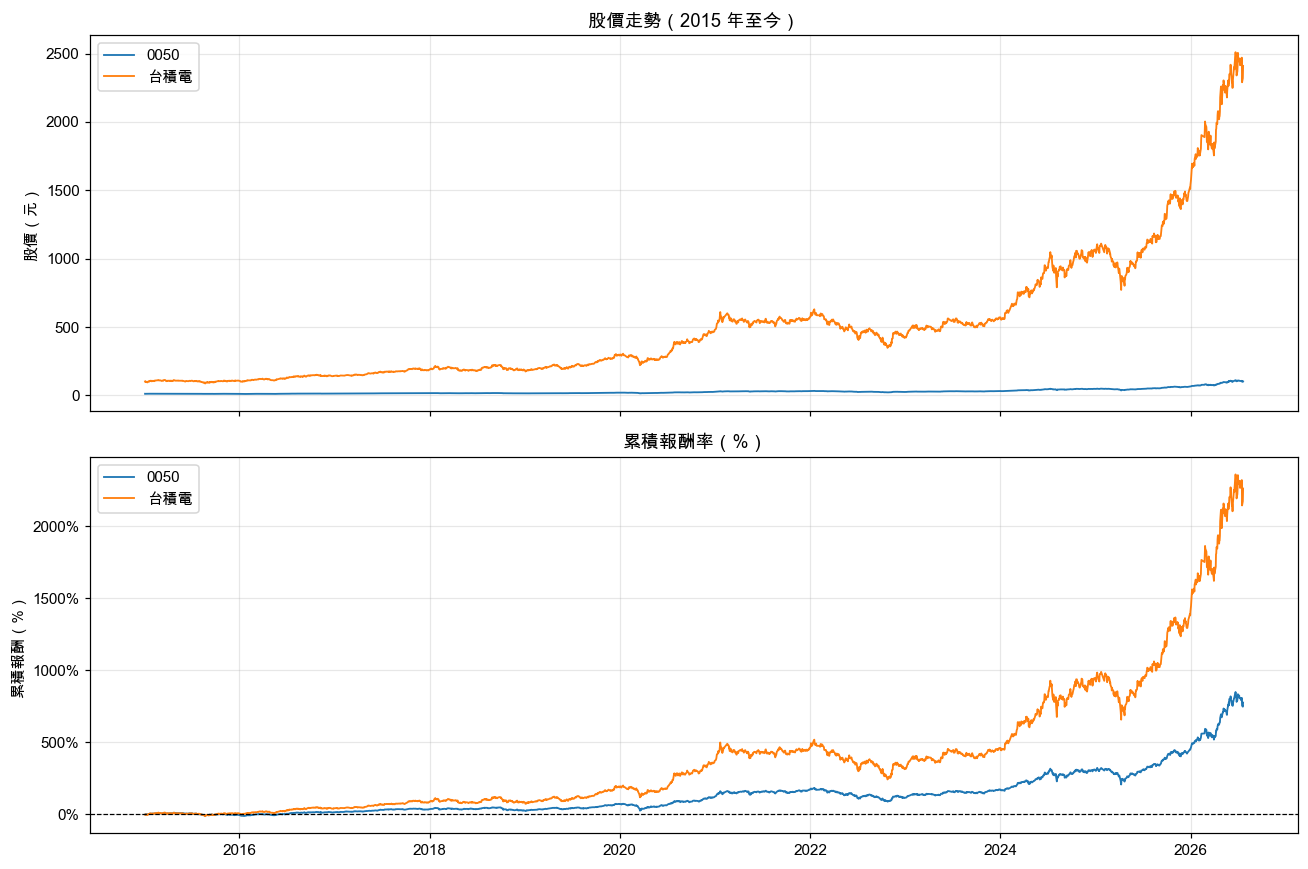

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# 上圖：股價走勢
for col in prices.columns:
    axes[0].plot(prices.index, prices[col], label=NAMES.get(col, col), linewidth=1.2)
axes[0].set_title('股價走勢（2015 年至今）')
axes[0].set_ylabel('股價（元）')
axes[0].legend()

# 下圖：累積報酬
for col in cum_returns.columns:
    axes[1].plot(cum_returns.index, cum_returns[col] * 100,
                 label=NAMES.get(col, col), linewidth=1.2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('累積報酬率（%）')
axes[1].set_ylabel('累積報酬（%）')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes[1].legend()

plt.tight_layout()
plt.show()

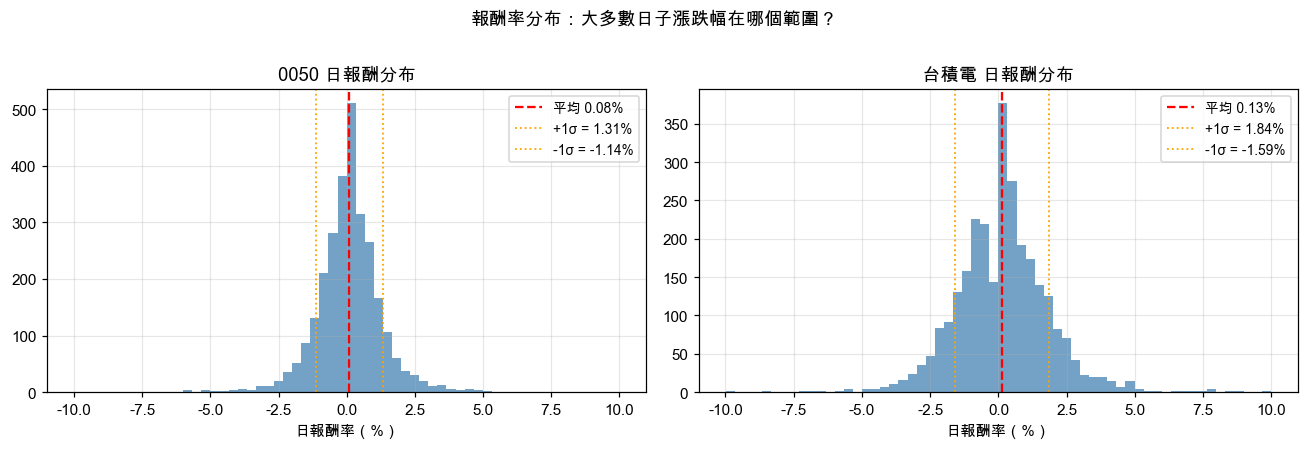


波動度比較（日報酬標準差）：
  0050：±1.23% / 天
  台積電：±1.72% / 天


In [7]:
# 報酬率分布：每天漲跌幅長什麼樣子？
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(returns.columns):
    name = NAMES.get(col, col)
    r = returns[col] * 100
    avg = r.mean()
    std = r.std()

    axes[i].hist(r, bins=60, color='steelblue', edgecolor='none', alpha=0.75)
    axes[i].axvline(avg, color='red', linestyle='--', linewidth=1.5,
                    label=f'平均 {avg:.2f}%')
    axes[i].axvline(avg + std, color='orange', linestyle=':', linewidth=1.2,
                    label=f'+1σ = {avg+std:.2f}%')
    axes[i].axvline(avg - std, color='orange', linestyle=':', linewidth=1.2,
                    label=f'-1σ = {avg-std:.2f}%')
    axes[i].set_title(f'{name} 日報酬分布')
    axes[i].set_xlabel('日報酬率（%）')
    axes[i].legend(fontsize=9)

plt.suptitle('報酬率分布：大多數日子漲跌幅在哪個範圍？', y=1.01)
plt.tight_layout()
plt.show()

print('\n波動度比較（日報酬標準差）：')
for col in returns.columns:
    name = NAMES.get(col, col)
    print(f'  {name}：±{returns[col].std()*100:.2f}% / 天')

---

## 六｜移動平均線

移動平均線是最常見的技術指標之一——把過去 N 天的收盤價平均起來，畫成一條線。

它的作用不是「預測未來」，而是**過濾短期雜訊，看出中期趨勢**。

pandas 的 `.rolling(N).mean()` 就搞定了。

> 等等的實證課程會說明：移動平均線的「訊號」，在統計上到底有沒有預測力。

In [ ]:
# 移動平均線用第一支股票示範
t0    = TICKERS[0]
name0 = NAMES.get(t0, t0)
p0    = prices[t0]

ma20  = p0.rolling(20).mean()    # 月線（約 20 個交易日）
ma60  = p0.rolling(60).mean()    # 季線（約 60 個交易日）
ma240 = p0.rolling(240).mean()   # 年線（約 240 個交易日）

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(p0.index,   p0,    label=f'{name0} 收盤價', color='#4C72B0', linewidth=1,   alpha=0.8)
ax.plot(ma20.index, ma20,  label='月線 (MA20)',      color='#DD8452', linewidth=1.5)
ax.plot(ma60.index, ma60,  label='季線 (MA60)',      color='#55A868', linewidth=1.5)
ax.plot(ma240.index,ma240, label='年線 (MA240)',     color='#C44E52', linewidth=2)

ax.set_title(f'{name0} 收盤價與移動平均線')
ax.set_ylabel('股價')
ax.legend()
plt.tight_layout()
plt.show()

---

## 七｜比較兩資產的關係

最後一個問題：你選的這幾支股票，漲跌有多像？

用**相關係數**量化：1 表示完全同向，0 表示毫無關係，-1 表示反向。

In [ ]:
corr = returns.corr()
print('日報酬相關係數矩陣：')
print(corr.round(3))

In [ ]:
# 散布圖：比較前兩支股票的每日報酬（如果只放一支則跳過）
if len(TICKERS) >= 2:
    t0, t1 = TICKERS[0], TICKERS[1]
    n0, n1 = NAMES.get(t0, t0), NAMES.get(t1, t1)
    r_val  = corr.loc[t0, t1]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(returns[t0] * 100, returns[t1] * 100,
               alpha=0.15, s=10, color='steelblue')

    lim = max(abs(returns.values.min()), abs(returns.values.max())) * 100 * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1, alpha=0.5, label='y = x')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)

    ax.set_xlabel(f'{n0} 日報酬（%）')
    ax.set_ylabel(f'{n1} 日報酬（%）')
    ax.set_title(f'{n0} vs {n1}（相關係數 = {r_val:.3f}）')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('只有一支股票，跳過散布圖')

---

## 這跟你有什麼關係？

今天這幾個操作——下載資料、算報酬率、畫圖、看相關係數——就是後面課程所有分析的地基。

但工具只是工具。有了工具之後，更重要的問題是：

- 移動平均線穿越是不是真的有預測力？（→ Notebook 08 月份效應會討論）
- 台積電和 0050 這麼相關，持有兩個算不算分散風險？（→ Notebook 10、11 因子投資）
- 過去十年報酬這麼好，未來還會一樣嗎？（→ Notebook 03 CAPE 估值）

這些問題，光靠畫圖是回答不了的，需要統計檢定和學術文獻的支撐。

那就是後面的課程要做的事。

---

## 📌 本章重點摘要

| 工具 | 用途 | 關鍵語法 |
|------|------|----------|
| `yfinance` | 下載股市資料 | `yf.download(ticker, start=...)` |
| `pct_change()` | 計算日報酬率 | `df.pct_change().dropna()` |
| `cumprod()` | 計算累積報酬 | `(1 + r).cumprod() - 1` |
| `rolling().mean()` | 移動平均線 | `df.rolling(20).mean()` |
| `corr()` | 相關係數矩陣 | `df.corr()` |
| `plt.subplots()` | 多子圖畫布 | `fig, axes = plt.subplots(2, 1)` |
| `ax.hist()` | 報酬分布直方圖 | `ax.hist(data, bins=60)` |

> **下一章：** 行為金融學——你的大腦在投資上為什麼這麼不可靠？